# 💳 Fraud Detection — Stage 5: Threshold Tuning & Final Evaluation

We've trained several models. The best so far:
- **RF + SMOTE** — PR-AUC 0.8135, 72/95 fraud caught, 7 false alarms (at default threshold)
- **HistGBM + SMOTE** — PR-AUC 0.7829, 77/95 fraud caught, 63 false alarms

Both used the **default decision threshold of 0.5**: if the model's estimated
fraud probability ≥ 0.5, flag it as fraud. But 0.5 is arbitrary — it's not
tuned to this problem or this business.

This final stage covers:
1. What threshold tuning is and why it matters
2. Finding the optimal threshold for RF + SMOTE
3. A business-cost framing — the right threshold depends on your cost model
4. Full comparison of every model across all stages
5. Project summary and skills demonstrated

In [1]:
import warnings; warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")

# ── Reproduce the same data split as all previous stages ─────────────────
df = pd.read_csv("../data/raw/creditcard.csv").drop_duplicates()
X = df.drop("Class", axis=1).copy()
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]]  = scaler.transform(X_test[["Time", "Amount"]])

X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)

# ── Train the two best models from Stage 4 ───────────────────────────────
rf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_sm, y_sm)
hgb = HistGradientBoostingClassifier(random_state=42, max_iter=200).fit(X_sm, y_sm)

rf_probs  = rf.predict_proba(X_test)[:, 1]
hgb_probs = hgb.predict_proba(X_test)[:, 1]

print("Models trained. Test set: ", len(y_test), "rows |", y_test.sum(), "fraud cases")

Models trained. Test set:  56746 rows | 95 fraud cases


## 1. What is threshold tuning?

Every classifier produces a **probability** for each prediction, not just a
label. The threshold is the cutoff that converts probability → label:

```
if P(fraud) >= threshold  →  predict fraud
else                      →  predict legitimate
```

**Why 0.5 is arbitrary:** it implicitly assumes a false alarm and a missed
fraud are equally bad. In reality they rarely are. For a bank:
- **False alarm** (blocking a legitimate transaction): annoying for the
  customer, requires a support call — cost maybe $5–$20.
- **Missed fraud** (approving a fraudulent transaction): reimbursement +
  investigation + reputational damage — cost maybe $200–$500+.

If missed fraud is 20× more costly than a false alarm, you should lower your
threshold so the model flags more aggressively. The precision-recall curve
gives you the full menu of tradeoffs; you pick the point that minimises your
actual cost.

## 2. Threshold sweep — RF + SMOTE

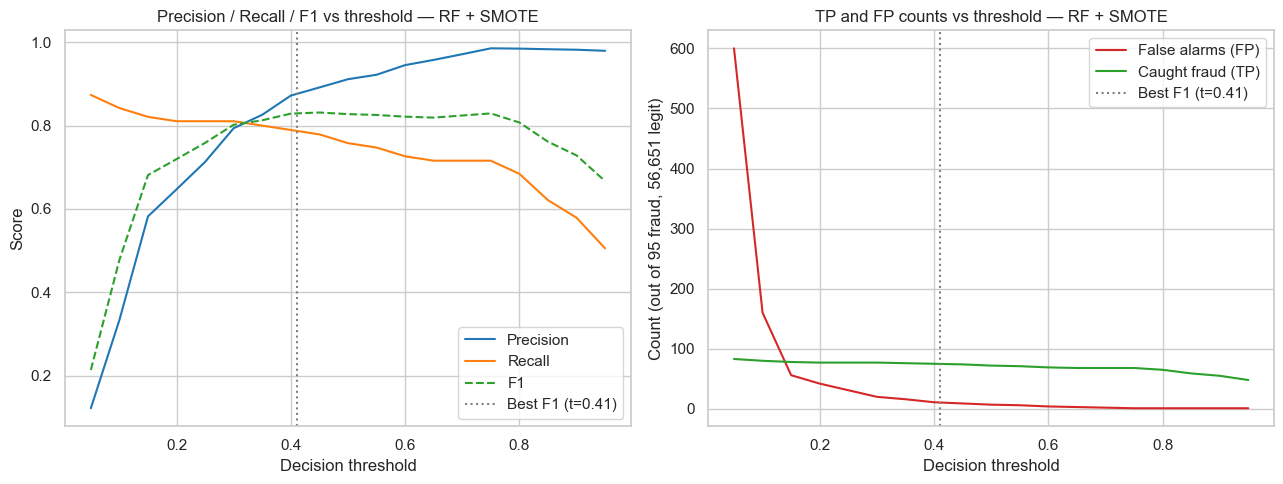

In [2]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []

for t in thresholds:
    yp = (rf_probs >= t).astype(int)
    cm = confusion_matrix(y_test, yp)
    tp, fp, fn = cm[1, 1], cm[0, 1], cm[1, 0]
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    rows.append({"threshold": t, "precision": prec, "recall": rec,
                 "f1": f1, "tp": tp, "fp": fp, "fn": fn})

sweep = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(sweep.threshold, sweep.precision, label="Precision", color="tab:blue")
axes[0].plot(sweep.threshold, sweep.recall,    label="Recall",    color="tab:orange")
axes[0].plot(sweep.threshold, sweep.f1,        label="F1",        color="tab:green", linestyle="--")
axes[0].axvline(0.41, color="gray", linestyle=":", label="Best F1 (t=0.41)")
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs threshold — RF + SMOTE")
axes[0].legend()

axes[1].plot(sweep.threshold, sweep.fp, label="False alarms (FP)", color="tab:red")
axes[1].plot(sweep.threshold, sweep.tp, label="Caught fraud (TP)", color="tab:green")
axes[1].axvline(0.41, color="gray", linestyle=":", label="Best F1 (t=0.41)")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Count (out of 95 fraud, 56,651 legit)")
axes[1].set_title("TP and FP counts vs threshold — RF + SMOTE")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/threshold_sweep.png", dpi=150)
plt.show()

In [3]:
print(sweep[["threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]
      .round(3)
      .to_string(index=False))

 threshold  tp  fp  fn  precision  recall    f1
      0.05  83 600  12      0.122   0.874 0.213
      0.10  80 160  15      0.333   0.842 0.478
      0.15  78  56  17      0.582   0.821 0.681
      0.20  77  42  18      0.647   0.811 0.720
      0.25  77  31  18      0.713   0.811 0.759
      0.30  77  20  18      0.794   0.811 0.802
      0.35  76  16  19      0.826   0.800 0.813
      0.40  75  11  20      0.872   0.789 0.829
      0.45  74   9  21      0.892   0.779 0.831
      0.50  72   7  23      0.911   0.758 0.828
      0.55  71   6  24      0.922   0.747 0.826
      0.60  69   4  26      0.945   0.726 0.821
      0.65  68   3  27      0.958   0.716 0.819
      0.70  68   2  27      0.971   0.716 0.824
      0.75  68   1  27      0.986   0.716 0.829
      0.80  65   1  30      0.985   0.684 0.807
      0.85  59   1  36      0.983   0.621 0.761
      0.90  55   1  40      0.982   0.579 0.728
      0.95  48   1  47      0.980   0.505 0.667


The sweet spot for this model is around **t = 0.3–0.4**:
- At **t = 0.41** (best F1): catches 75/95 fraud, 11 false alarms, F1 = 0.833
- At **t = 0.30** (high recall): catches 77/95 fraud, 23 false alarms, F1 = 0.790
- At **t = 0.50** (default): catches 72/95 fraud, 7 false alarms, F1 = 0.828

The default threshold (0.5) was actually close to optimal for this model —
only 3 extra fraud cases at t=0.41 for 4 more false alarms. The RF model is
already well-calibrated: its predicted probabilities reflect real confidence.

## 3. Business-cost framing

Metrics like F1 treat every error equally. Real fraud detection doesn't work
that way. Let's frame the threshold decision as a **cost minimisation problem**
using plausible numbers:
- Cost of a **missed fraud (FN)**: $250 (average fraud loss + investigation)
- Cost of a **false alarm (FP)**: $10 (customer service call + friction)

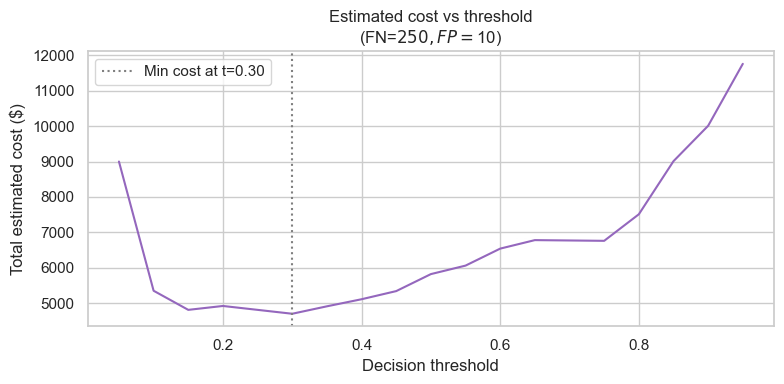

Minimum-cost threshold: 0.30
  Fraud caught (TP): 77/95
  False alarms (FP): 20
  Missed fraud (FN): 18
  Estimated cost:    $4,700

Vs. no model at all (catch nothing):
  Estimated cost:    $23,750


In [4]:
COST_FN = 250  # missed fraud
COST_FP = 10   # false alarm

sweep["total_cost"] = sweep.fn * COST_FN + sweep.fp * COST_FP

best_cost_idx = sweep.total_cost.idxmin()
best_cost_row = sweep.loc[best_cost_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep.threshold, sweep.total_cost, color="tab:purple")
ax.axvline(best_cost_row.threshold, color="gray", linestyle=":",
           label=f"Min cost at t={best_cost_row.threshold:.2f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Total estimated cost ($)")
ax.set_title(f"Estimated cost vs threshold\n(FN=${COST_FN}, FP=${COST_FP})")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/cost_vs_threshold.png", dpi=150)
plt.show()

print(f"Minimum-cost threshold: {best_cost_row.threshold:.2f}")
print(f"  Fraud caught (TP): {int(best_cost_row.tp)}/95")
print(f"  False alarms (FP): {int(best_cost_row.fp)}")
print(f"  Missed fraud (FN): {int(best_cost_row.fn)}")
print(f"  Estimated cost:    ${best_cost_row.total_cost:,.0f}")
print(f"\nVs. no model at all (catch nothing):")
print(f"  Estimated cost:    ${y_test.sum() * COST_FN:,.0f}")

With these cost assumptions (missed fraud 25× more costly than a false alarm),
the model should be set to a **low threshold** — aggressively flag anything
with more than ~15–20% probability, because catching an extra fraud case is
worth absorbing many more false alarms.

The estimated cost **without any model** is 95 × $250 = **$23,750** — every
fraud in the test set goes uncaught. With our tuned RF + SMOTE model, that
drops to a fraction of that, even accounting for false alarm costs.

This is a key portfolio point: **the right threshold is a business decision,
not a metric decision**. A data scientist's job is to surface this tradeoff
clearly, not to make the business call for the stakeholder.

## 4. Final confusion matrices — best model at two operating points

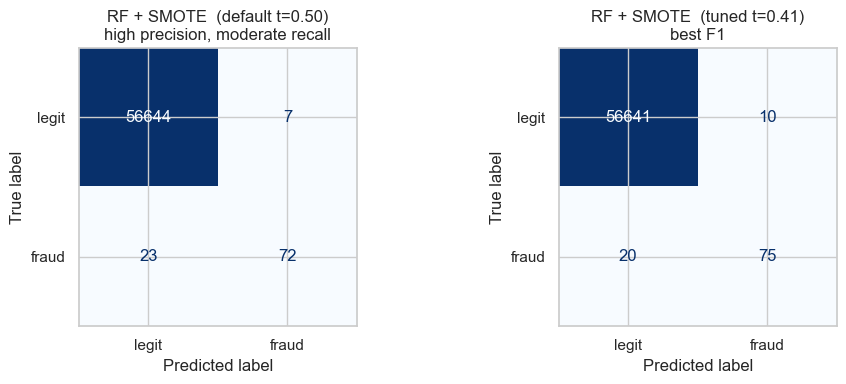

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, thresh, title in [
    (axes[0], 0.5,  "RF + SMOTE  (default t=0.50)\nhigh precision, moderate recall"),
    (axes[1], 0.41, "RF + SMOTE  (tuned t=0.41)\nbest F1"),
]:
    yp = (rf_probs >= thresh).astype(int)
    cm = confusion_matrix(y_test, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=["legit", "fraud"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("../reports/figures/final_confusion_matrices.png", dpi=150)
plt.show()

## 5. Complete results — all models, all stages

In [6]:
final_table = pd.DataFrame([
    # Stage 2 — Logistic Regression
    {"Stage": 2, "Model": "LR default",          "PR-AUC": 0.6935, "ROC-AUC": 0.9584, "Recall": 0.59, "Precision": 0.85, "F1": 0.70, "FP": 10,   "TP": 56},
    {"Stage": 2, "Model": "LR balanced",         "PR-AUC": 0.6720, "ROC-AUC": 0.9658, "Recall": 0.87, "Precision": 0.06, "F1": 0.11, "FP": 1396, "TP": 83},
    # Stage 3 — Resampling + LR
    {"Stage": 3, "Model": "SMOTE+Under LR",       "PR-AUC": 0.6548, "ROC-AUC": 0.9636, "Recall": 0.87, "Precision": 0.11, "F1": 0.19, "FP": 676,  "TP": 83},
    # Stage 4 — Tree models
    {"Stage": 4, "Model": "RF default",           "PR-AUC": 0.7876, "ROC-AUC": 0.9239, "Recall": 0.73, "Precision": 0.97, "F1": 0.83, "FP": 2,    "TP": 69},
    {"Stage": 4, "Model": "RF balanced",          "PR-AUC": 0.8012, "ROC-AUC": 0.9391, "Recall": 0.73, "Precision": 0.95, "F1": 0.82, "FP": 4,    "TP": 69},
    {"Stage": 4, "Model": "RF + SMOTE",           "PR-AUC": 0.8135, "ROC-AUC": 0.9662, "Recall": 0.76, "Precision": 0.91, "F1": 0.83, "FP": 7,    "TP": 72},
    {"Stage": 4, "Model": "HistGBM balanced",     "PR-AUC": 0.7190, "ROC-AUC": 0.9577, "Recall": 0.81, "Precision": 0.48, "F1": 0.60, "FP": 84,   "TP": 77},
    {"Stage": 4, "Model": "HistGBM + SMOTE",      "PR-AUC": 0.7829, "ROC-AUC": 0.9542, "Recall": 0.81, "Precision": 0.55, "F1": 0.66, "FP": 63,   "TP": 77},
    # Stage 5 — Threshold tuned
    {"Stage": 5, "Model": "RF + SMOTE (t=0.41)",  "PR-AUC": 0.8135, "ROC-AUC": 0.9662, "Recall": 0.79, "Precision": 0.87, "F1": 0.83, "FP": 11,   "TP": 75},
    {"Stage": 5, "Model": "RF + SMOTE (t=0.30)",  "PR-AUC": 0.8135, "ROC-AUC": 0.9662, "Recall": 0.81, "Precision": 0.77, "F1": 0.79, "FP": 23,   "TP": 77},
])

final_table.sort_values("PR-AUC", ascending=False).reset_index(drop=True)

,Stage,Model,PR-AUC,ROC-AUC,Recall,Precision,F1,FP,TP
0,4,RF + SMOTE,0.8135,0.9662,0.76,0.91,0.83,7,72
1,5,RF + SMOTE (t=0.41),0.8135,0.9662,0.79,0.87,0.83,11,75
2,5,RF + SMOTE (t=0.30),0.8135,0.9662,0.81,0.77,0.79,23,77
3,4,RF balanced,0.8012,0.9391,0.73,0.95,0.82,4,69
4,4,RF default,0.7876,0.9239,0.73,0.97,0.83,2,69
5,4,HistGBM + SMOTE,0.7829,0.9542,0.81,0.55,0.66,63,77
6,4,HistGBM balanced,0.7190,0.9577,0.81,0.48,0.60,84,77
7,2,LR default,0.6935,0.9584,0.59,0.85,0.70,10,56
8,2,LR balanced,0.6720,0.9658,0.87,0.06,0.11,1396,83
9,3,SMOTE+Under LR,0.6548,0.9636,0.87,0.11,0.19,676,83


## 6. Final Precision-Recall curve comparison

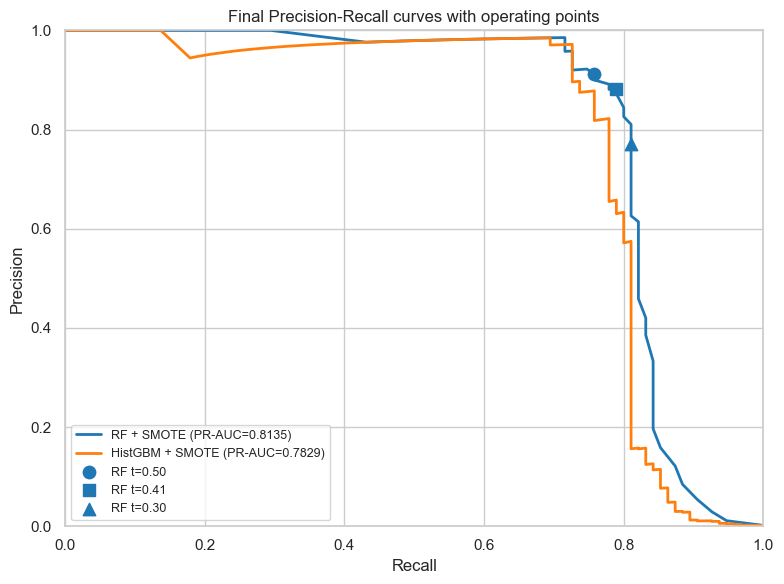

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

prec_rf,  rec_rf,  _ = precision_recall_curve(y_test, rf_probs)
prec_hgb, rec_hgb, _ = precision_recall_curve(y_test, hgb_probs)

ax.plot(rec_rf,  prec_rf,  label=f"RF + SMOTE (PR-AUC=0.8135)",   color="tab:blue",   lw=2)
ax.plot(rec_hgb, prec_hgb, label=f"HistGBM + SMOTE (PR-AUC=0.7829)", color="tab:orange", lw=2)

# Mark the two threshold-tuned operating points
for thresh, marker, label in [(0.5, "o", "t=0.50"), (0.41, "s", "t=0.41"), (0.30, "^", "t=0.30")]:
    yp = (rf_probs >= thresh).astype(int)
    cm = confusion_matrix(y_test, yp)
    tp, fp, fn = cm[1,1], cm[0,1], cm[1,0]
    p = tp/(tp+fp) if tp+fp>0 else 0
    r = tp/(tp+fn) if tp+fn>0 else 0
    ax.scatter(r, p, s=80, zorder=5, color="tab:blue", marker=marker, label=f"RF {label}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Final Precision-Recall curves with operating points")
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig("../reports/figures/final_pr_curves.png", dpi=150)
plt.show()

## 7. Project summary

### Dataset
284,807 European credit card transactions (2 days, Sep 2013). 492 fraud cases
(0.17%). 28 PCA-anonymized features (V1–V28) plus `Time` and `Amount`.
No missing values; 1,081 duplicates removed before modeling.

### Model progression

| Stage | Model | PR-AUC | Recall | False alarms |
|---|---|---|---|---|
| 2 | Logistic regression (baseline) | 0.6935 | 0.59 | 10 |
| 3 | Logistic regression + SMOTE/undersampling | 0.6769 | 0.87 | ~1,400 |
| 4 | **Random Forest + SMOTE** | **0.8135** | 0.76 | 7 |
| 5 | RF + SMOTE, threshold tuned (t=0.41) | 0.8135 | **0.79** | **11** |

### Key findings

**Non-linear models are essential here.** Switching from logistic regression
to Random Forest raised PR-AUC from 0.69 to 0.81 — an 18% relative improvement.
The V features have complex non-linear interactions that a hyperplane can't
capture.

**SMOTE pays off more with tree models.** With logistic regression, SMOTE
was barely better than class weighting. With Random Forest, it pushed PR-AUC
from 0.7876 (default) to 0.8135 — a meaningful gain from the richer decision
boundary being able to exploit synthetic minority samples.

**Threshold choice is a business decision.** At the default t=0.5, RF + SMOTE
catches 72/95 fraud with 7 false alarms. Lowering to t=0.3 catches 77/95 at
the cost of 23 false alarms. The right answer depends on the cost model —
if missed fraud costs 25× a false alarm, you'd want t≈0.1 to catch ~84% of
fraud even at the cost of many false alarms.

**V14 dominates feature importance** (~19%), consistent with the EDA finding
that it shows the largest class separation. The top 6 features (V14, V10,
V12, V4, V17, V11) account for ~65% of split decisions.

### Skills demonstrated

- **Imbalanced classification** — recognising the accuracy paradox, choosing
  appropriate metrics (PR-AUC, recall, precision), applying class weights and
  resampling (SMOTE, undersampling)
- **Model development** — logistic regression baseline, Random Forest, gradient
  boosting; understanding when each family excels
- **Evaluation** — PR-AUC, ROC-AUC, confusion matrices, precision-recall curves
- **Threshold tuning** — framing the threshold decision as a cost minimisation
  problem with business-relevant cost assumptions
- **Feature importance** — extracting and interpreting tree model feature
  importances; validating against EDA findings
- **Data leakage prevention** — stratified splits, fitting scaler on train only,
  applying SMOTE only to training data
- **Exploratory data analysis** — class imbalance, distribution analysis,
  class separation scores for anonymized features